# COM 837 Assignment 2, Q2
### 16-QAM demodulation with K-means

Run `generate_qam_dataset.py` first so `qam16_dataset.csv` is in this folder.
Written observations for every part are in the PDF report.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

SNR_LIST = [0, 5, 10, 15, 20, 25, 30]
K = 16                    # constellation points
SEED = 42

df = pd.read_csv('qam16_dataset.csv')
df.shape

(22400, 6)

## Part (a) - amplitude and phase

In [2]:
# arctan2, not arctan(Q/I): a plain arctan folds four quadrants onto two and
# would give symbols in opposite quadrants the same phase
df['r'] = np.sqrt(df.rx_I ** 2 + df.rx_Q ** 2)
df['theta'] = np.arctan2(df.rx_Q, df.rx_I)

df[['rx_I', 'rx_Q', 'r', 'theta']].head()

,rx_I,rx_Q,r,theta
0,-0.150698,-0.451184,0.475686,-1.893151
1,-0.846724,-0.901808,1.237012,-2.324702
2,-1.737290,-1.182234,2.101394,-2.544071
3,-0.078202,0.315637,0.325181,1.813665
4,-1.058043,-0.077369,1.060868,-3.068598


In [3]:
# radii and phases of the noiseless grid
grid = df.groupby('symbol_id')[['tx_I', 'tx_Q']].first()
grid['r'] = np.hypot(grid.tx_I, grid.tx_Q)
grid['theta_deg'] = np.degrees(np.arctan2(grid.tx_Q, grid.tx_I))

print('radii :', np.round(sorted(grid.r.unique()), 4))
print('phases:', np.round(sorted(grid.theta_deg.unique()), 2))

radii : [0.4472 1.     1.3416]
phases: [-161.57 -135.   -108.43  -71.57  -45.    -18.43   18.43   45.     71.57
  108.43  135.    161.57]


## Part (b) - choosing K, and Cartesian vs polar (25 dB only)

In [4]:
sub25 = df[df.snr_db == 25]
cart25 = sub25[['rx_I', 'rx_Q']].values

k_range = range(2, 21)
inertia, silhouette = [], []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED).fit(cart25)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(cart25, km.labels_))

sweep = pd.DataFrame({'inertia': inertia, 'silhouette': silhouette}, index=list(k_range))
sweep.index.name = 'K'
sweep.round(3)

,inertia,silhouette
K,,
2,1926.791,0.389
3,1196.420,0.417
4,651.338,0.510
5,570.343,0.478
6,501.473,0.489
7,410.813,0.514
8,328.891,0.542
9,287.399,0.563
10,248.139,0.583


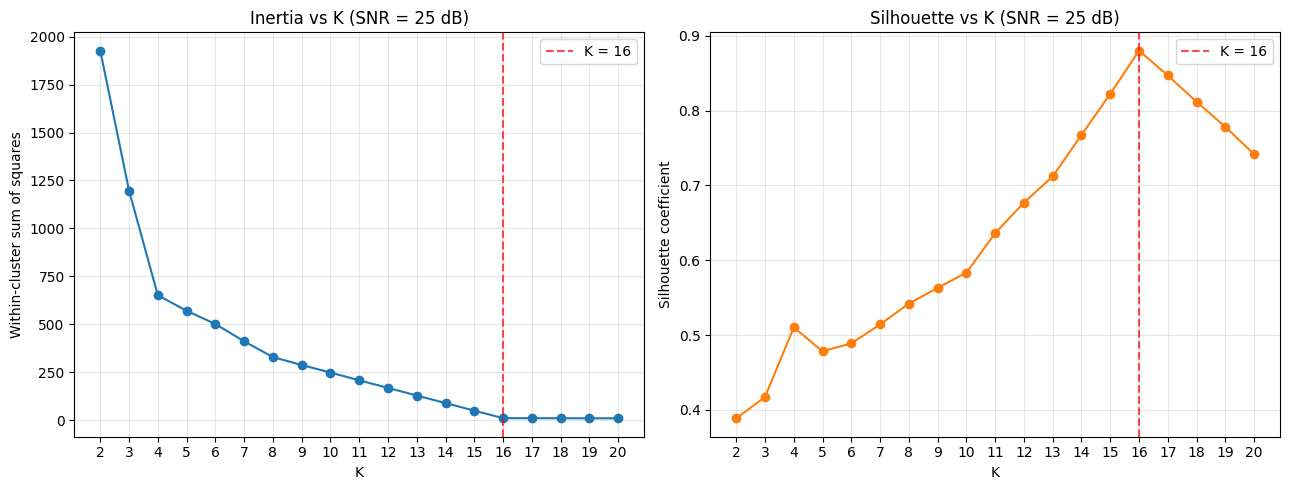

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))

left.plot(sweep.index, sweep.inertia, marker='o')
left.axvline(K, color='red', linestyle='--', alpha=0.7, label='K = 16')
left.set_xlabel('K'); left.set_ylabel('Within-cluster sum of squares')
left.set_title('Inertia vs K (SNR = 25 dB)')
left.set_xticks(list(k_range)); left.grid(alpha=0.3); left.legend()

right.plot(sweep.index, sweep.silhouette, marker='o', color='tab:orange')
right.axvline(K, color='red', linestyle='--', alpha=0.7, label='K = 16')
right.set_xlabel('K'); right.set_ylabel('Silhouette coefficient')
right.set_title('Silhouette vs K (SNR = 25 dB)')
right.set_xticks(list(k_range)); right.grid(alpha=0.3); right.legend()

plt.tight_layout()
plt.savefig('q2_elbow_silhouette.png', dpi=150)
plt.show()

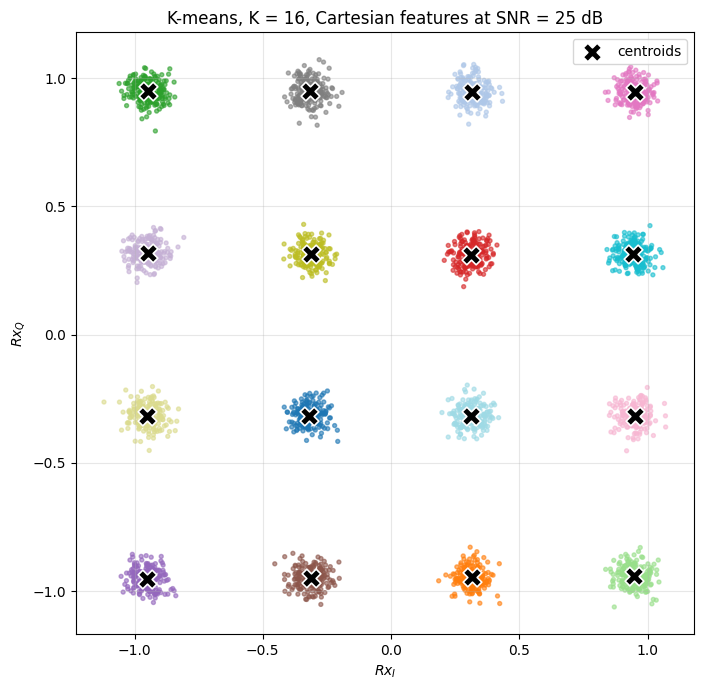

worst centroid error 0.0070, symbol spacing 0.6325


In [6]:
km16 = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED).fit(cart25)

plt.figure(figsize=(7.5, 7))
plt.scatter(cart25[:, 0], cart25[:, 1], c=km16.labels_, cmap='tab20', s=8, alpha=0.6)
plt.scatter(km16.cluster_centers_[:, 0], km16.cluster_centers_[:, 1], c='black',
            marker='X', s=180, edgecolors='white', linewidths=1.2, label='centroids')
plt.xlabel('$Rx_I$'); plt.ylabel('$Rx_Q$')
plt.title('K-means, K = 16, Cartesian features at SNR = 25 dB')
plt.legend(); plt.grid(alpha=0.3); plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig('q2_kmeans16_scatter.png', dpi=150)
plt.show()

# distance from each learned centroid to the nearest true symbol
true_xy = grid[['tx_I', 'tx_Q']].values
gaps = [np.min(np.linalg.norm(true_xy - c, axis=1)) for c in km16.cluster_centers_]
print(f'worst centroid error {max(gaps):.4f}, symbol spacing {2 / np.sqrt(10):.4f}')

In [7]:
def purity(clusters, truth):
    # each cluster takes the label of its most common true symbol
    hits = sum(np.bincount(truth[clusters == c], minlength=K).max()
               for c in np.unique(clusters))
    return 100 * hits / len(truth)


def cluster_purity(features, truth):
    km = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED).fit(features)
    return purity(km.labels_, truth)

In [8]:
truth25 = sub25.symbol_id.values

feature_sets = {
    'Set 1 (rx_I, rx_Q)':  sub25[['rx_I', 'rx_Q']].values,
    'Set 2 (r, theta)':    sub25[['r', 'theta']].values,
    'Set 3 all four':      StandardScaler().fit_transform(       # scaled, as required
                               sub25[['rx_I', 'rx_Q', 'r', 'theta']].values),
}

for name, features in feature_sets.items():
    print(f'{name:22s} {cluster_purity(features, truth25):6.2f} %')

Set 1 (rx_I, rx_Q)     100.00 %
Set 2 (r, theta)       100.00 %
Set 3 all four         100.00 %


In [9]:
# all three are perfect at 25 dB, so repeat the comparison across the sweep
rows = []
for snr in SNR_LIST:
    sub = df[df.snr_db == snr]
    truth = sub.symbol_id.values
    rows.append([cluster_purity(sub[['rx_I', 'rx_Q']].values, truth),
                 cluster_purity(sub[['r', 'theta']].values, truth),
                 cluster_purity(StandardScaler().fit_transform(
                     sub[['rx_I', 'rx_Q', 'r', 'theta']].values), truth)])

pd.DataFrame(rows, index=SNR_LIST,
             columns=['Cartesian', 'Polar', 'Both scaled']).round(2)

,Cartesian,Polar,Both scaled
0,24.25,23.88,23.66
5,42.16,41.38,39.50
10,77.34,67.38,70.69
15,98.34,96.59,96.88
20,99.97,99.97,99.97
25,100.00,100.00,100.00
30,100.00,100.00,100.00


## Part (c) - fresh fit per SNR vs fixed 25 dB centroids

In [10]:
template = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED).fit(cart25)

adaptive, fixed = [], []
for snr in SNR_LIST:
    sub = df[df.snr_db == snr]
    cart = sub[['rx_I', 'rx_Q']].values
    truth = sub.symbol_id.values

    fresh = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED).fit(cart)
    adaptive.append(purity(fresh.labels_, truth))
    fixed.append(purity(template.predict(cart), truth))

acc_c = pd.DataFrame({'Adaptive K-Means': adaptive, 'Fixed Template': fixed},
                     index=SNR_LIST)
acc_c.index.name = 'snr_db'
acc_c.round(2)

,Adaptive K-Means,Fixed Template
snr_db,,
0,24.25,26.06
5,42.16,47.53
10,77.34,77.53
15,98.34,98.31
20,99.97,99.97
25,100.00,100.00
30,100.00,100.00


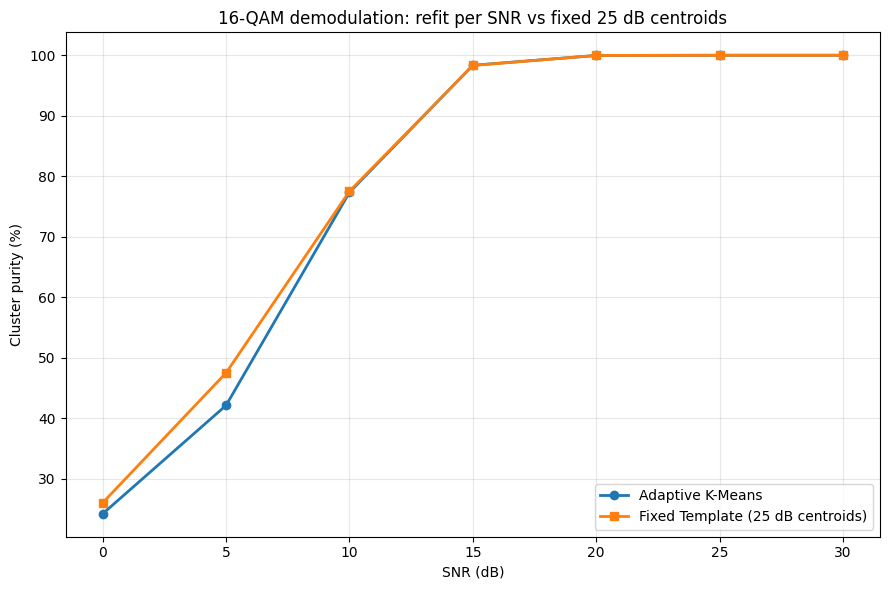

In [11]:
plt.figure(figsize=(9, 6))
plt.plot(acc_c.index, acc_c['Adaptive K-Means'], marker='o', linewidth=2,
         label='Adaptive K-Means')
plt.plot(acc_c.index, acc_c['Fixed Template'], marker='s', linewidth=2,
         label='Fixed Template (25 dB centroids)')

plt.xlabel('SNR (dB)'); plt.ylabel('Cluster purity (%)')
plt.title('16-QAM demodulation: refit per SNR vs fixed 25 dB centroids')
plt.xticks(SNR_LIST); plt.grid(alpha=0.3); plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('q2_adaptive_vs_template.png', dpi=150)
plt.show()

In [12]:
# an ML detector on the true grid as an upper reference, and a count of how many
# of the 16 symbols the clusters actually claim as their majority label
def symbols_covered(clusters, truth):
    return len({np.bincount(truth[clusters == c], minlength=K).argmax()
                for c in np.unique(clusters)})

print(' snr    ML   adaptive (covered)   template (covered)')
for snr in SNR_LIST:
    sub = df[df.snr_db == snr]
    cart = sub[['rx_I', 'rx_Q']].values
    truth = sub.symbol_id.values

    ml = ((cart[:, None, :] - true_xy[None]) ** 2).sum(axis=2).argmin(axis=1)
    fresh = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED).fit(cart)
    pred = template.predict(cart)

    print(f'{snr:4d}  {100 * (ml == truth).mean():6.2f}   '
          f'{purity(fresh.labels_, truth):6.2f} ({symbols_covered(fresh.labels_, truth):2d})'
          f'{purity(pred, truth):14.2f} ({symbols_covered(pred, truth):2d})')

 snr    ML   adaptive (covered)   template (covered)
   0   26.00    24.25 (11)         26.06 (15)
   5   47.69    42.16 (15)         47.53 (16)
  10   77.34    77.34 (16)         77.53 (16)
  15   98.38    98.34 (16)         98.31 (16)
  20   99.97    99.97 (16)         99.97 (16)
  25  100.00   100.00 (16)        100.00 (16)
  30  100.00   100.00 (16)        100.00 (16)


In [13]:
# where the 0 dB centroids drift to
fresh0 = KMeans(n_clusters=K, init='k-means++', n_init=10,
                random_state=SEED).fit(df[df.snr_db == 0][['rx_I', 'rx_Q']].values)

mean_radius = lambda c: np.hypot(c[:, 0], c[:, 1]).mean()
print(f'adaptive at 0 dB {mean_radius(fresh0.cluster_centers_):.3f}')
print(f'25 dB template   {mean_radius(template.cluster_centers_):.3f}')
print(f'true grid        {mean_radius(true_xy):.3f}')

adaptive at 0 dB 1.397
25 dB template   0.946
true grid        0.947
